In [ ]:
!pip install download

In [ ]:
from download import download

In [ ]:
path=download("https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip",path=".",kind='zip',replace=True)


file_sizes: 7.96MB [00:00, 13.4MB/s]
Extracting zip file...
Successfully downloaded / unzipped to .


In [ ]:
import pandas as pd
df=pd.read_csv("/content/PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling
1,2,2013,3,1,1,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling
2,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling
3,4,2013,3,1,3,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling
4,5,2013,3,1,4,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling


In [ ]:
df['date/time']=pd.to_datetime(df['year'].astype(str)+" "+df['month'].astype(str)+" "+df['day'].astype(str)+" "+df['hour'].astype(str),format="%Y %m %d %H")

In [ ]:
df.drop(['year','month','day','hour'],axis=1,inplace=True)

In [ ]:
df.head()

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date/time
0,1,4.0,4.0,3.0,NaN,200.0,82.0,-2.3,1020.8,-19.7,0.0,E,0.5,Dingling,2013-03-01 00:00:00
1,2,7.0,7.0,3.0,NaN,200.0,80.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Dingling,2013-03-01 01:00:00
2,3,5.0,5.0,3.0,2.0,200.0,79.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Dingling,2013-03-01 02:00:00
3,4,6.0,6.0,3.0,NaN,200.0,79.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Dingling,2013-03-01 03:00:00
4,5,5.0,5.0,3.0,NaN,200.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Dingling,2013-03-01 04:00:00


In [ ]:
df.isnull().sum()

,0
No,0
PM2.5,779
PM10,656
SO2,730
NO2,1234
CO,2012
O3,1214
TEMP,53
PRES,50
DEWP,53


In [ ]:
# null!=null so it will give all values where temp is null
df.query("TEMP !=TEMP")

,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,date/time
16748,16749,39.0,43.0,28.0,34.0,1100.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-01-27 20:00:00
16813,16814,15.0,19.0,19.0,5.0,400.0,68.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-01-30 13:00:00
16829,16830,5.0,11.0,32.0,8.0,400.0,60.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-01-31 05:00:00
16873,16874,60.0,60.0,30.0,39.0,2600.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-02 01:00:00
16883,16884,138.0,138.0,52.0,73.0,2200.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-02 11:00:00
16930,16931,8.0,8.0,13.0,5.0,200.0,69.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-04 10:00:00
16933,16934,13.0,16.0,14.0,3.0,300.0,68.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-04 13:00:00
17007,17008,3.0,24.0,2.0,2.0,200.0,88.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-07 15:00:00
17030,17031,4.0,5.0,7.0,2.0,200.0,80.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-08 14:00:00
17052,17053,87.0,87.0,82.0,53.0,1600.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,Dingling,2015-02-09 12:00:00


In [ ]:
import plotly.express as px

fig=px.line(df,x='date/time',y='TEMP')
fig.update_xaxes(rangeslider_visible=True)

In [ ]:
df.set_index('date/time',inplace=True)

In [ ]:
# analaysing before imputation
# autocorelation plot

sm_df=df.loc["2013":"2015"]
sm_df.resample("1m")['TEMP'].mean()

/tmp/ipython-input-1461943153.py:5: FutureWarning:

'm' is deprecated and will be removed in a future version, please use 'ME' instead.



,TEMP
date/time,
2013-03-31,5.904032
2013-04-30,12.412222
2013-05-31,21.985618
2013-06-30,23.706389
2013-07-31,27.271640
2013-08-31,26.967339
2013-09-30,20.380278
2013-10-31,13.427419
2013-11-30,6.698333


/tmp/ipython-input-2546471168.py:1: FutureWarning:

'm' is deprecated and will be removed in a future version, please use 'ME' instead.



<Axes: xlabel='Lag', ylabel='Autocorrelation'>

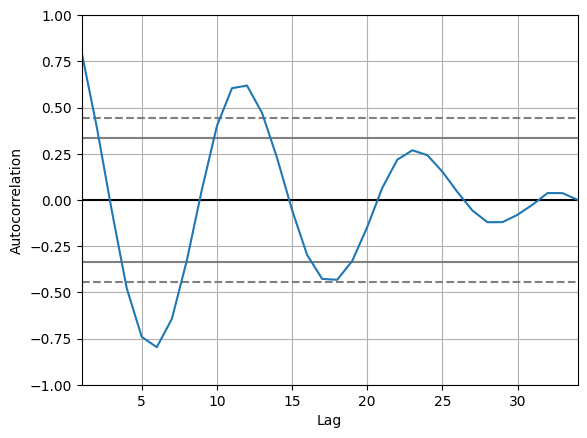

In [ ]:
pd.plotting.autocorrelation_plot(sm_df.resample("1m")['TEMP'].mean())
# this shows a high correlation in 12 months interval

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

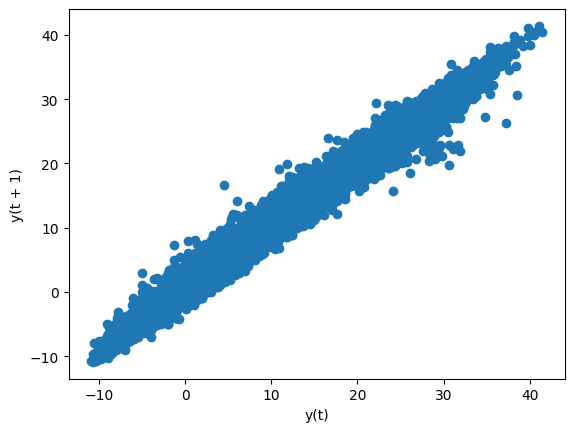

In [ ]:
# here data's frequency is hourly so lag=1 mean's hourly diffrence
pd.plotting.lag_plot(sm_df['TEMP'],lag=1)

<Axes: xlabel='y(t)', ylabel='y(t + 3)'>

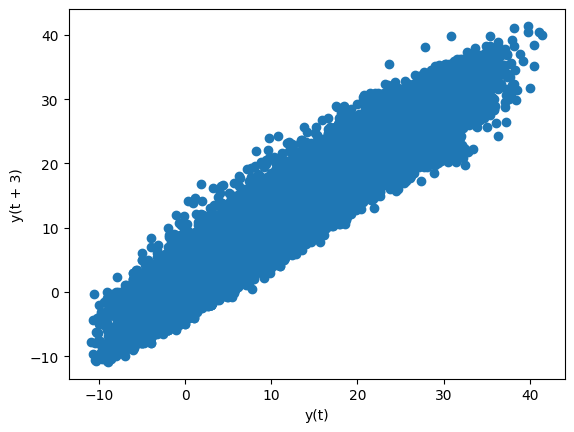

In [ ]:
pd.plotting.lag_plot(sm_df['TEMP'],lag=3)

<Axes: xlabel='y(t)', ylabel='y(t + 24)'>

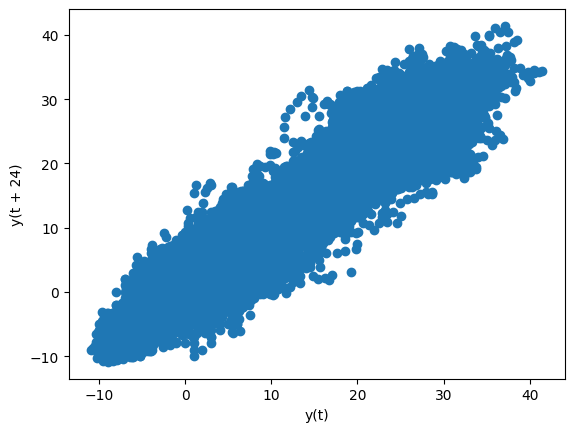

In [ ]:
pd.plotting.lag_plot(sm_df['TEMP'],lag=24)

<Axes: xlabel='y(t)', ylabel='y(t + 8640)'>

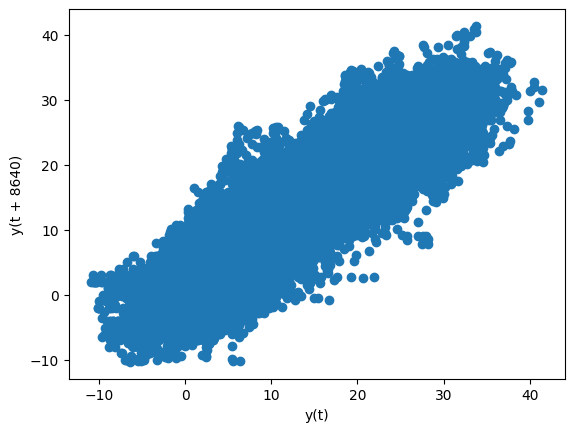

In [ ]:
pd.plotting.lag_plot(sm_df['TEMP'],lag=8640)

In [ ]:
# taking few hrs interval for better analysation
sm_df=df.loc["2015-02-21 10":"2015-02-21 23"][["TEMP"]]

In [ ]:
sm_df

,TEMP
date/time,
2015-02-21 10:00:00,1.0
2015-02-21 11:00:00,1.0
2015-02-21 12:00:00,NaN
2015-02-21 13:00:00,2.0
2015-02-21 14:00:00,NaN
2015-02-21 15:00:00,4.0
2015-02-21 16:00:00,4.0
2015-02-21 17:00:00,3.0
2015-02-21 18:00:00,2.0


In [ ]:
# for ward fill -> fill with previous value
sm_df['ffill']=sm_df['TEMP'].fillna(method='ffill')
sm_df

/tmp/ipython-input-2664480818.py:2: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



,TEMP,ffill
date/time,,
2015-02-21 10:00:00,1.0,1.0
2015-02-21 11:00:00,1.0,1.0
2015-02-21 12:00:00,NaN,1.0
2015-02-21 13:00:00,2.0,2.0
2015-02-21 14:00:00,NaN,2.0
2015-02-21 15:00:00,4.0,4.0
2015-02-21 16:00:00,4.0,4.0
2015-02-21 17:00:00,3.0,3.0
2015-02-21 18:00:00,2.0,2.0


In [ ]:
sm_df['bfill']=sm_df['TEMP'].fillna(method='bfill')
sm_df

/tmp/ipython-input-646436284.py:1: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



,TEMP,ffill,bfill
date/time,,,
2015-02-21 10:00:00,1.0,1.0,1.0
2015-02-21 11:00:00,1.0,1.0,1.0
2015-02-21 12:00:00,NaN,1.0,2.0
2015-02-21 13:00:00,2.0,2.0,2.0
2015-02-21 14:00:00,NaN,2.0,4.0
2015-02-21 15:00:00,4.0,4.0,4.0
2015-02-21 16:00:00,4.0,4.0,4.0
2015-02-21 17:00:00,3.0,3.0,3.0
2015-02-21 18:00:00,2.0,2.0,2.0


In [ ]:
# filling with rolling window
sm_df['temp_rolling']=sm_df['TEMP'].rolling(3,min_periods=1).mean()
sm_df

,TEMP,ffill,bfill,temp_rolling
date/time,,,,
2015-02-21 10:00:00,1.0,1.0,1.0,1.000000
2015-02-21 11:00:00,1.0,1.0,1.0,1.000000
2015-02-21 12:00:00,NaN,1.0,2.0,1.000000
2015-02-21 13:00:00,2.0,2.0,2.0,1.500000
2015-02-21 14:00:00,NaN,2.0,4.0,2.000000
2015-02-21 15:00:00,4.0,4.0,4.0,3.000000
2015-02-21 16:00:00,4.0,4.0,4.0,4.000000
2015-02-21 17:00:00,3.0,3.0,3.0,3.666667
2015-02-21 18:00:00,2.0,2.0,2.0,3.000000


In [ ]:
# with previous year same date and hour
df.loc[sm_df.index+pd.offsets.DateOffset(years=-1)]['TEMP']

,TEMP
date/time,
2014-02-21 10:00:00,1.4
2014-02-21 11:00:00,2.4
2014-02-21 12:00:00,3.0
2014-02-21 13:00:00,3.8
2014-02-21 14:00:00,3.5
2014-02-21 15:00:00,3.6
2014-02-21 16:00:00,3.3
2014-02-21 17:00:00,2.8
2014-02-21 18:00:00,1.3


In [87]:
sm_df.apply(lambda x:df.loc[pd.to_datetime(x.name)+pd.offsets.DateOffset(years=-1)]['TEMP'] if pd.isna(x['TEMP']) else x['TEMP'],axis=1)

,0
date/time,
2015-02-21 10:00:00,1.0
2015-02-21 11:00:00,1.0
2015-02-21 12:00:00,3.0
2015-02-21 13:00:00,2.0
2015-02-21 14:00:00,3.5
2015-02-21 15:00:00,4.0
2015-02-21 16:00:00,4.0
2015-02-21 17:00:00,3.0
2015-02-21 18:00:00,2.0


In [ ]:
pd.offsets.DateOffset(years=-1)

<DateOffset: years=-1>